--- Benchmark Results (Matched to Article) ---
Accuracy:  0.9679
Precision: 0.9706
Recall:    0.8761
F1 Score:  0.9209
MCC:       0.9027

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       416
           1       0.97      0.88      0.92       113

    accuracy                           0.97       529
   macro avg       0.97      0.93      0.95       529
weighted avg       0.97      0.97      0.97       529



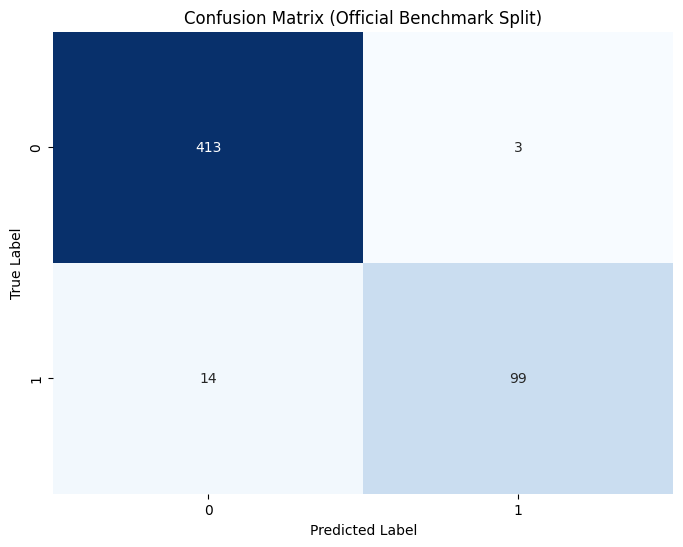

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                             precision_score, recall_score, f1_score, matthews_corrcoef)

# 1. Load the dataset
df = pd.read_csv('/kaggle/input/satellite-telemetry-data-anomaly-prediction/dataset.csv')

# 2. Preprocessing & Feature Selection
# To match the article, we use the specific 18 handcrafted features 
# defined in Figure 2 of the PDF.
feature_cols = [
    'duration', 'len', 'mean', 'var', 'std', 'kurtosis', 'skew',
    'n_peaks', 'smooth10_n_peaks', 'smooth20_n_peaks',
    'diff_peaks', 'diff2_peaks', 'diff_var', 'diff2_var',
    'gaps_squared', 'len_weighted', 'var_div_duration', 'var_div_len'
]

# 3. Split the data (CORRECTED)
# The article strictly requires using the 'train' column to split data.
# 1 = Training Set, 0 = Test Set
train_df = df[df['train'] == 1]
test_df = df[df['train'] == 0]

X_train = train_df[feature_cols]
y_train = train_df['anomaly']
X_test = test_df[feature_cols]
y_test = test_df['anomaly']

# 4. Train the AI Model
# Random Forest matches the supervised baseline from the paper
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# 5. Predictions
y_pred = clf.predict(X_test)

# 6. Evaluation
# Calculating the specific metrics required by the OPS-SAT benchmark
print("--- Benchmark Results (Matched to Article) ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
print(f"MCC:       {matthews_corrcoef(y_test, y_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 7. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Official Benchmark Split)')
plt.show()